# Parcial 1 – Análisis de Productividad de Estudiantes
Notebook estructurado para resolver los incisos (a–i).

## a) Cargar y mostrar el conjunto de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv("student_productivity.csv")
df

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,26,Female,4.81,7.83,6.86,6.93,2.77,5.68,6,451,0,11,63.69,3,89,82.13,60.43
19996,19997,22,Other,0.83,4.49,6.76,3.79,2.95,1.38,1,375,13,4,74.06,10,56,87.12,17.84
19997,19998,25,Male,9.36,4.33,2.94,6.98,0.35,1.42,4,413,1,11,73.18,9,69,81.58,65.56
19998,19999,22,Female,0.74,4.44,3.15,5.99,3.11,5.01,7,319,1,6,77.02,5,53,53.04,28.06


## b) Mostrar las primeras y últimas 10 observaciones

In [2]:
df.head(10)

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
0,1,23,Female,4.35,3.63,3.38,2.73,1.83,5.26,6,347,111,2,57.21,10,57,81.87,33.78
1,2,20,Male,6.14,6.58,5.48,1.51,3.13,1.73,13,403,28,10,91.27,10,49,60.90,48.99
2,3,29,Female,4.98,3.26,4.83,3.63,0.18,4.71,1,419,102,8,63.14,2,38,86.22,36.60
3,4,27,Female,3.19,4.58,10.06,3.95,5.75,2.52,9,178,28,18,40.51,6,50,71.77,19.87
4,5,24,Male,7.67,6.21,3.02,1.59,5.46,5.65,8,436,105,7,45.53,6,41,90.13,52.90
5,6,29,Other,7.18,3.52,4.02,3.74,1.42,0.16,10,392,12,3,47.58,10,70,59.48,47.31
6,7,21,Female,9.06,6.36,11.45,5.99,2.20,4.44,14,87,28,15,43.50,8,35,62.71,41.23
7,8,23,Female,6.37,4.86,3.31,1.37,4.36,5.13,2,152,103,17,75.22,6,59,52.22,53.81
8,9,26,Male,4.19,4.87,9.66,2.87,0.10,3.38,13,460,42,11,44.79,3,39,76.15,25.99
9,10,19,Female,7.28,9.56,2.13,0.81,1.35,2.55,7,416,107,6,79.15,10,73,88.53,73.18


In [3]:
df.tail(10)

,student_id,age,gender,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
19990,19991,22,Female,9.27,9.44,5.55,6.57,4.55,4.84,8,202,21,16,71.13,5,96,44.85,87.45
19991,19992,28,Female,2.72,5.55,4.66,2.70,3.77,2.52,11,332,73,11,61.53,10,78,91.75,37.35
19992,19993,23,Male,3.63,6.50,1.19,0.48,1.00,1.42,3,450,43,1,45.31,3,78,95.21,54.39
19993,19994,28,Female,9.41,6.99,2.86,0.42,2.75,5.40,10,140,101,3,69.17,8,41,99.31,64.44
19994,19995,20,Male,9.84,4.99,5.27,0.70,2.11,1.44,9,340,49,1,99.33,5,78,82.19,77.10
19995,19996,26,Female,4.81,7.83,6.86,6.93,2.77,5.68,6,451,0,11,63.69,3,89,82.13,60.43
19996,19997,22,Other,0.83,4.49,6.76,3.79,2.95,1.38,1,375,13,4,74.06,10,56,87.12,17.84
19997,19998,25,Male,9.36,4.33,2.94,6.98,0.35,1.42,4,413,1,11,73.18,9,69,81.58,65.56
19998,19999,22,Female,0.74,4.44,3.15,5.99,3.11,5.01,7,319,1,6,77.02,5,53,53.04,28.06
19999,20000,19,Female,3.64,6.35,8.68,0.11,5.19,1.28,8,50,70,9,40.08,9,65,72.70,30.37


## c) Describir las variables junto al tipo de variable

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  str    
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  focus_score  

In [5]:
df.dtypes

student_id                 int64
age                        int64
gender                       str
study_hours_per_day      float64
sleep_hours              float64
phone_usage_hours        float64
social_media_hours       float64
youtube_hours            float64
gaming_hours             float64
breaks_per_day             int64
coffee_intake_mg           int64
exercise_minutes           int64
assignments_completed      int64
attendance_percentage    float64
stress_level               int64
focus_score                int64
final_grade              float64
productivity_score       float64
dtype: object

## d) Estadísticos para las variables numéricas

In [6]:
df.describe()

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,23.00745,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,5773.647028,3.75489,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,1.000000,17.00000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,5000.750000,20.00000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,10000.500000,23.00000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,15000.250000,26.00000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,20000.000000,29.00000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


## e) Histogramas de variables seleccionadas

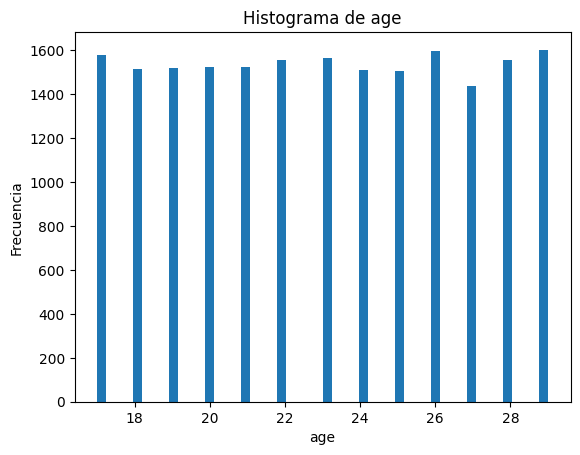

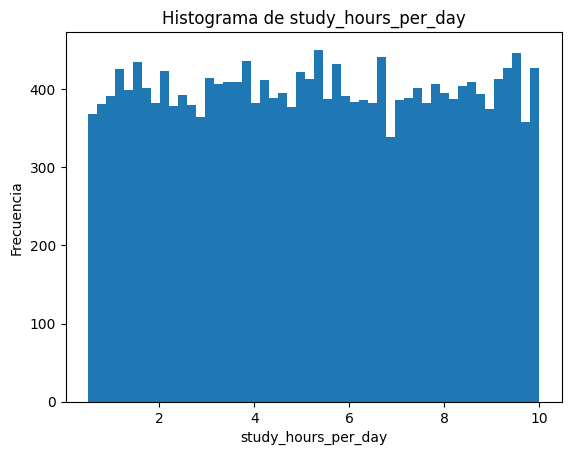

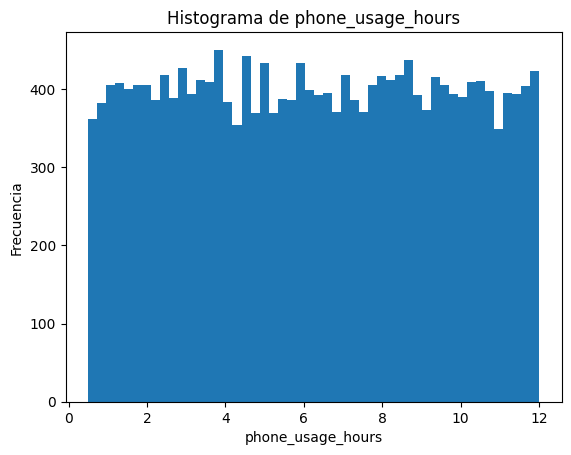

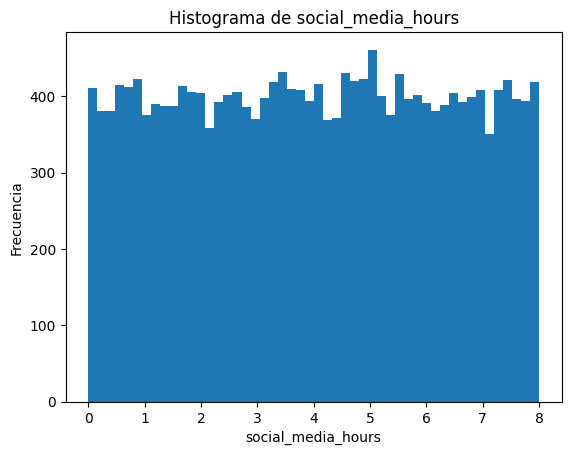

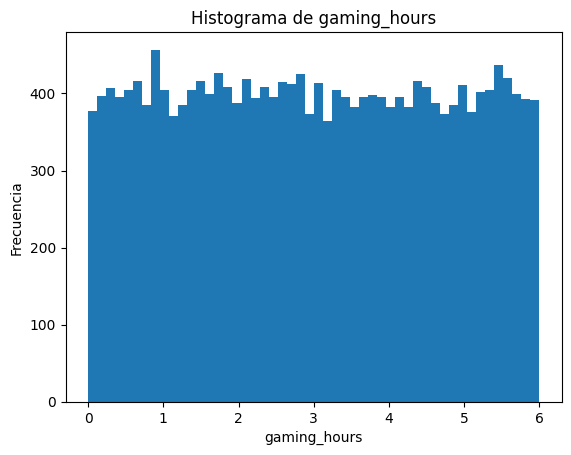

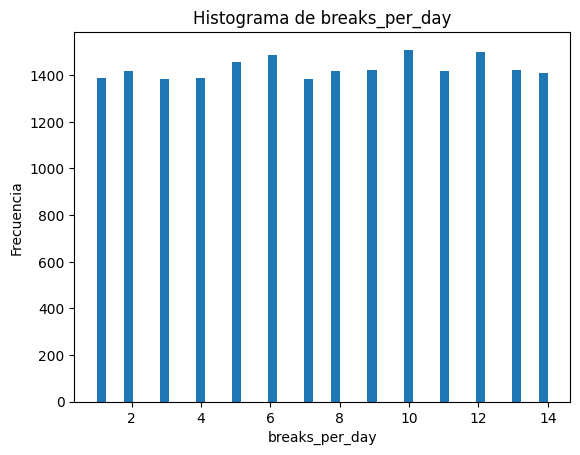

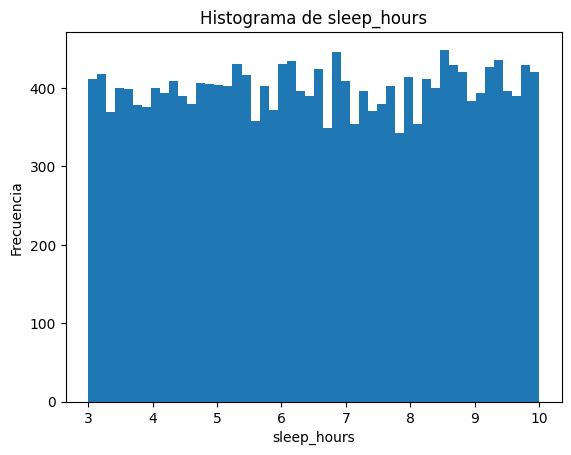

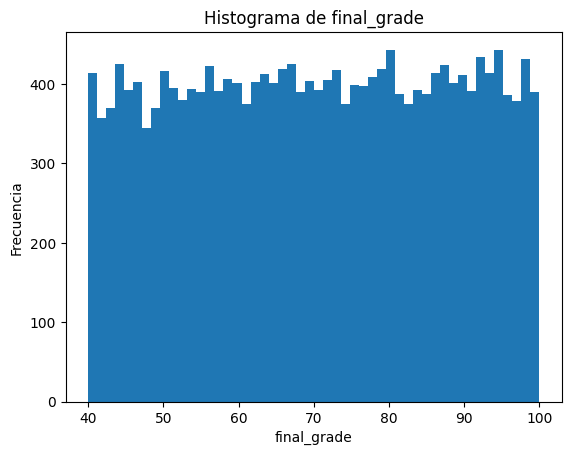

In [9]:
variables = [
    "age",
    "study_hours_per_day",
    "phone_usage_hours",
    "social_media_hours",
    "gaming_hours",
    "breaks_per_day",
    "sleep_hours",
    "final_grade"
]

for v in variables:
    plt.hist(df[v], bins=50)
    plt.title("Histograma de " + v)
    plt.xlabel(v)
    plt.ylabel("Frecuencia")
    plt.show()

## f) Matriz de correlación

In [10]:
variables_corr = [
    "study_hours_per_day",
    "phone_usage_hours",
    "social_media_hours",
    "gaming_hours",
    "sleep_hours",
    "focus_score",
    "productivity_score",
    "final_grade"
]

correlation_matrix = df[variables_corr].corr()
correlation_matrix

,study_hours_per_day,phone_usage_hours,social_media_hours,gaming_hours,sleep_hours,focus_score,productivity_score,final_grade
study_hours_per_day,1.000000,0.011539,0.004888,-0.002104,0.001670,0.004536,0.732777,-0.012208
phone_usage_hours,0.011539,1.000000,0.004030,-0.007497,0.000016,-0.000206,-0.326650,-0.012136
social_media_hours,0.004888,0.004030,1.000000,0.006406,-0.005939,-0.001285,0.001285,-0.000117
gaming_hours,-0.002104,-0.007497,0.006406,1.000000,-0.003666,-0.001462,0.000685,0.002544
sleep_hours,0.001670,0.000016,-0.005939,-0.003666,1.000000,-0.003241,0.340902,0.010543
focus_score,0.004536,-0.000206,-0.001285,-0.001462,-0.003241,1.000000,0.411366,0.004630
productivity_score,0.732777,-0.326650,0.001285,0.000685,0.340902,0.411366,1.000000,0.001954
final_grade,-0.012208,-0.012136,-0.000117,0.002544,0.010543,0.004630,0.001954,1.000000


## g) Gráfico de dispersión (ejemplo con focus_score y productivity_score)

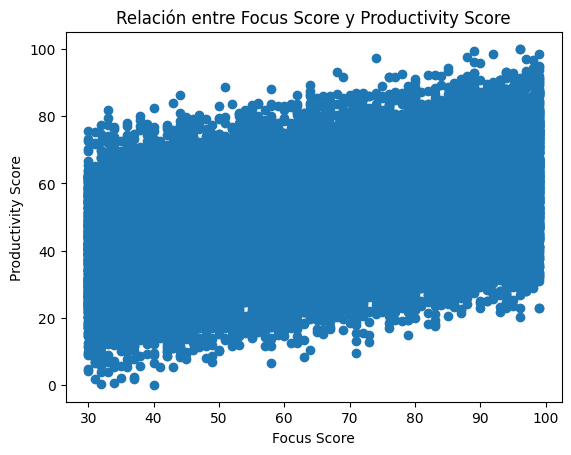

In [11]:
plt.scatter(df["focus_score"], df["productivity_score"])
plt.xlabel("Focus Score")
plt.ylabel("Productivity Score")
plt.title("Relación entre Focus Score y Productivity Score")
plt.show()

## h) Trimedia para la variable final_grade

In [12]:
Q1 = df["final_grade"].quantile(0.25)
Q2 = df["final_grade"].quantile(0.50)
Q3 = df["final_grade"].quantile(0.75)

trimedia = (Q1 + 2*Q2 + Q3) / 4
print("Trimedia:", trimedia)

Trimedia: 70.3575


## i) Media recortada 20% y centrimedia para sleep_hours

In [13]:
media_recortada = stats.trim_mean(df["sleep_hours"], 0.20)
print("Media recortada 20%:", media_recortada)

Q1 = df["sleep_hours"].quantile(0.25)
Q2 = df["sleep_hours"].quantile(0.50)
Q3 = df["sleep_hours"].quantile(0.75)

centrimedia = (Q1 + Q2 + Q3) / 3
print("Centrimedia:", centrimedia)

Media recortada 20%: 6.522168333333332
Centrimedia: 6.53
